In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from langdetect import detect
from langdetect.lang_detect_exception import LangDetectException
from pymongo import MongoClient

## Validasi Dataset

In [2]:
# Load dataset
df = pd.read_csv("dataset/arxiv_papers_2020_2025.csv")

# Fungsi deteksi bahasa
def is_english(text):
    try:
        return detect(str(text)) == 'en'
    except LangDetectException:
        return False

# Tambahkan kolom deteksi bahasa
df['is_english'] = df['summary'].apply(is_english)

# Filter artikel berbahasa Inggris
df_english = df[df['is_english']]

# Filter artikel yang dieliminasi
df_non_english = df[~df['is_english']]

# Simpan keduanya
df_english.to_csv("validated_dataset_2020-20205.csv", index=False)
df_non_english.to_csv("eliminated dataset.csv_2020-2025", index=False)

# Statistik
print(f"Total artikel      : {len(df)}")
print(f"Berbahasa Inggris : {len(df_english)}")
print(f"Dieliminasi        : {len(df_non_english)}")


Total artikel      : 206509
Berbahasa Inggris : 206493
Dieliminasi        : 16


## Exploratory Data Analysis

In [3]:
df = pd.read_csv("200K Data/validated_dataset_2020-20205.csv")
print(df.shape)

(206493, 10)


In [4]:
df.columns

Index(['id', 'title', 'authors', 'summary', 'published', 'updated',
       'primary_category', 'categories', 'pdf_url', 'is_english'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206493 entries, 0 to 206492
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   id                206493 non-null  object
 1   title             206493 non-null  object
 2   authors           206493 non-null  object
 3   summary           206493 non-null  object
 4   published         206493 non-null  object
 5   updated           206493 non-null  object
 6   primary_category  206493 non-null  object
 7   categories        206493 non-null  object
 8   pdf_url           206493 non-null  object
 9   is_english        206493 non-null  bool  
dtypes: bool(1), object(9)
memory usage: 14.4+ MB


In [6]:
print(df.isnull().sum())

id                  0
title               0
authors             0
summary             0
published           0
updated             0
primary_category    0
categories          0
pdf_url             0
is_english          0
dtype: int64


In [12]:
duplicates = df[df.duplicated()]
print(f"Jumlah duplikat keseluruhan: {len(duplicates)}")

Jumlah duplikat keseluruhan: 27271


In [13]:
duplicate_by_title_summary = df[df.duplicated(subset=['title', 'summary'])]
print(f"Total duplikat berdasarkan title dan summary: {len(duplicate_by_title_summary)}")

Total duplikat berdasarkan title dan summary: 27279


In [17]:
duplicates = df[df.duplicated(subset=['title', 'summary', 'published'])]
print(duplicates[['title', 'published']])

                                                    title   published
19945   Forecasting in Non-stationary Environments wit...  2020-04-27
20189   Urban Bike Lane Planning with Bike Trajectorie...  2020-08-21
20234   A Column Generation based Heuristic for the Ta...  2020-09-25
20292   Scientific intuition inspired by machine learn...  2020-10-27
20594   Realistic Differentially-Private Transmission ...  2021-03-25
...                                                   ...         ...
206423  3D Holographic Flow Cytometry Measurements of ...  2025-06-04
206458  High-gain MIMO Beamforming Antenna System for ...  2025-06-02
206474  Quantitative Error Feedback for Quantization N...  2025-06-02
206476  Tram Positioning with Map-Enabled GNSS Data Re...  2025-06-02
206491  Conceal Truth while Show Fake: T/F Frequency M...  2025-06-01

[27271 rows x 2 columns]


In [15]:
# Kembalikan semua baris yang memiliki duplikat
all_duplicates = df[df.duplicated(subset=['title', 'summary'], keep=False)]

# Urutkan agar mudah dilihat
all_duplicates_sorted = all_duplicates.sort_values(by=['title'])

# Tampilkan
print(all_duplicates_sorted[['title', 'summary']].head(20))


                                                    title  \
50568        "Adversarial Examples" for Proof-of-Learning   
5991         "Adversarial Examples" for Proof-of-Learning   
203329  "Benefit Game: Alien Seaweed Swarms" -- Real-t...   
16587   "Benefit Game: Alien Seaweed Swarms" -- Real-t...   
168396  "Closed Proportional-Integral-Derivative-Loop ...   
188017  "Closed Proportional-Integral-Derivative-Loop ...   
200356  "Do it my way!": Impact of Customizations on T...   
13751   "Do it my way!": Impact of Customizations on T...   
147621  "Dyadosyncrasy", Idiosyncrasy and Demographic ...   
44472   "Dyadosyncrasy", Idiosyncrasy and Demographic ...   
69490   "Excavating AI" Re-excavated: Debunking a Fall...   
5531    "Excavating AI" Re-excavated: Debunking a Fall...   
57374   "False negative -- that one is going to kill y...   
113932  "False negative -- that one is going to kill y...   
22439   "Guinea Pig Trials" Utilizing GPT: A Novel Sma...   
130828  "Guinea Pig Tria

In [16]:
all_duplicates_sorted.to_csv("duplikat_artikel.csv", index=False)

In [ ]:
#Menghapus duplikasi 
df_cleaned = df.drop_duplicates(subset=['title', 'summary', 'published'])

print(f"Dataset setelah hapus duplikat: {df_cleaned.shape}")

df_cleaned.to_csv("200k Data/cleaned_validated_dataset.csv", index=False)

Dataset setelah hapus duplikat: (179222, 10)


In [19]:
#Load data yang sudah dibersihkan dari duplikasi
df_cleaned = pd.read_csv("200K Data/cleaned_validated_dataset.csv")

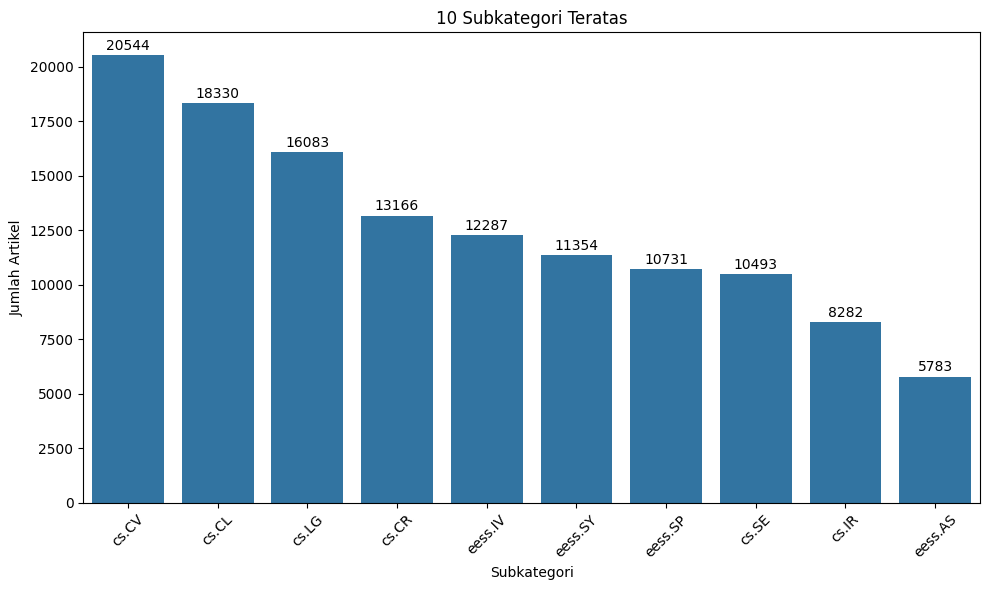

In [21]:
plt.figure(figsize=(10,6))

# Ambil 10 subkategori teratas
top_cats = df_cleaned['primary_category'].value_counts().nlargest(10)

# Plot diagram batang
ax = sns.barplot(x=top_cats.index, y=top_cats.values)

for i, value in enumerate(top_cats.values):
    ax.text(i, value + 100, str(value), ha='center', va='bottom')

plt.title("10 Subkategori Teratas")
plt.xticks(rotation=45)
plt.ylabel("Jumlah Artikel")
plt.xlabel("Subkategori")
plt.tight_layout()
plt.show()

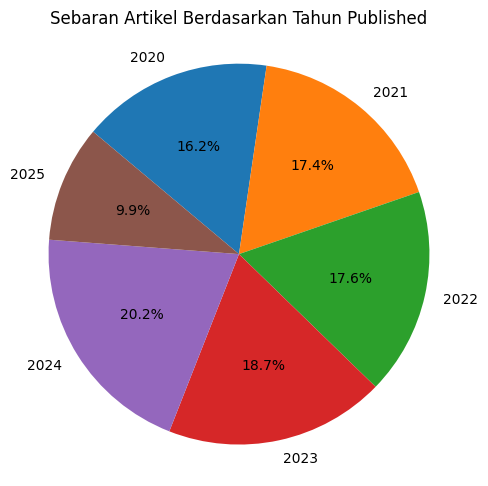

In [ ]:
#Visualisasi sebaran artikel berdasarkan tahun published
df_cleaned['published'] = pd.to_datetime(df_cleaned['published'], errors='coerce')

df_cleaned['year'] = df_cleaned['published'].dt.year

# Hitung jumlah artikel per tahun
year_counts = df_cleaned['year'].value_counts().sort_index()

# Plot pie chart
plt.figure(figsize=(5, 5))
plt.pie(year_counts.values,
        labels=year_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        counterclock=False)
plt.title("Sebaran Artikel Berdasarkan Tahun Publikasi")
plt.axis('equal')
plt.tight_layout()
plt.show()

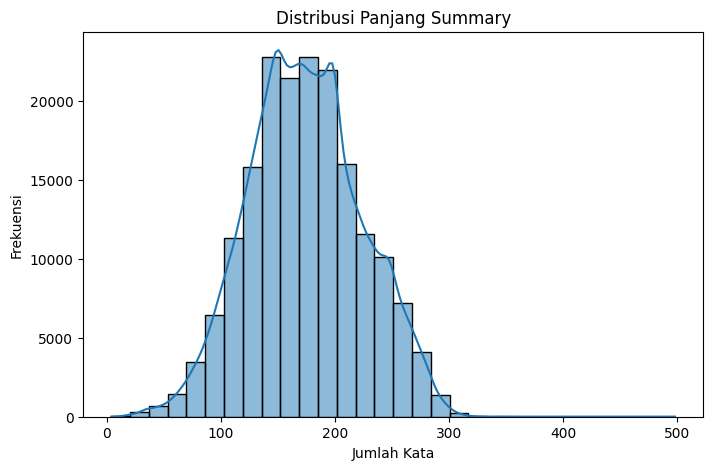

In [22]:
df_cleaned['summary_length'] = df_cleaned['summary'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(8,5))
sns.histplot(df_cleaned['summary_length'], bins=30, kde=True)
plt.title("Distribusi Panjang Summary")
plt.xlabel("Jumlah Kata")
plt.ylabel("Frekuensi")
plt.show()

In [27]:
df_cleaned.shape

(179222, 12)

## Koneksi ke MongoDB

In [ ]:
def connect_to_mongodb(uri="mongodb://localhost:27017", db_name="arxiv_db", collection_name="170k_papers"):
    client = MongoClient(uri)
    db = client[db_name]
    return db[collection_name]

def load_csv_to_dict(csv_path):
    df = pd.read_csv(csv_path)
    return df.to_dict(orient="records")

def insert_data(collection, data):
    if data:
        collection.insert_many(data)
        print(f"{len(data)} documents has successfully saved to MongoDB.")
    else:
        print("Empty Data.")

In [8]:
csv_path = "200K Data/cleaned_validated_dataset.csv"
collection = connect_to_mongodb()
data = load_csv_to_dict(csv_path)
insert_data(collection, data)

179222 documents has successfully saved to MongoDB.
